# Comparing WGCNA results from phase 1 and phase 2 oysters

I've identified modules from WGCNA ([phase 1 oysters](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/wgcna/wgcna_p1.ipynb) and [phase 2 oysters](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/wgcna/wgcna_p2.ipynb)) that are significantly correlated with water and DO treatments

I'm interested if there is overlap in the modules that I've identified between phase 1 and phase 2 oysters

## 0. load libraries

In [3]:
library(tidyverse)
library(UpSetR)

## 1. load CSVs

#### phase 1 oysters

In [7]:
p1_modules <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/p1.wgcna_GeneInfo.csv')
dim(p1_modules) # 13277 genes across 14 modules
head(p1_modules, 3)

[1] 13277    43

,Gene,GO.terms,ModuleColor,phase1_temp.GS.warm,phase1_temp.GS.ambient,phase1_DO.GS.hypoxic,phase1_DO.GS.normoxic,phase1_treatment.GS.both,phase1_treatment.GS.control,phase1_treatment.GS.hypoxic,⋯,MMdarkgreen,MMturquoise,MMblack,MMtan,MMlightgreen,MMlightcyan,MMdarkorange,MMgreenyellow,MMdarkred,MMwhite
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,COX2,GO:0004129; GO:0005507; GO:0005743; GO:0070469,cyan,-0.2002618,0.2002618,-0.1017792,0.1017792,-0.32960471,0.03398997,0.1938264,⋯,0.2424788,0.3764425,0.05708880,-0.121567508,-0.05321238,-0.3373683,-0.4778543,-0.5968790,0.06015678,-0.1030147
2,COX3,GO:0004129; GO:0005743; GO:0008535; GO:0019646; GO:0045277,cyan,0.1848033,-0.1848033,-0.1754977,0.1754977,-0.07944662,-0.08521314,-0.1250178,⋯,0.3811689,0.2699948,-0.03282921,-0.129676056,-0.33864040,-0.2506377,-0.3653076,-0.7762514,-0.05646699,-0.2144529
3,CYTB,GO:0005743; GO:0008121; GO:0022904; GO:0045275; GO:0046872,cyan,0.1884373,-0.1884373,-0.2020471,0.2020471,-0.10256367,-0.08085939,-0.1335056,⋯,0.2257259,0.2518677,-0.36272854,0.002679583,-0.30850184,-0.4185898,-0.2951800,-0.4936426,-0.27020281,-0.4346506


In [8]:
sort(table(p1_modules$ModuleColor), decreasing = TRUE)


         blue     turquoise   greenyellow          cyan         brown 
         2631          1764          1638          1261          1212 
          red     lightcyan         black          pink       magenta 
          957           783           582           563           455 
          tan  midnightblue        salmon   lightyellow    darkorange 
          259           155           153           125           117 
       grey60    lightgreen     royalblue       darkred     darkgreen 
           99            87            77            69            64 
     darkgrey         white darkturquoise        orange 
           60            58            55            53 

In [9]:
p1_modules.list <- split(p1_modules$Gene, p1_modules$ModuleColor)

names(p1_modules.list)
head(p1_modules.list$blue)

[1] "black"         "blue"          "brown"         "cyan"         
 [5] "darkgreen"     "darkgrey"      "darkorange"    "darkred"      
 [9] "darkturquoise" "greenyellow"   "grey60"        "lightcyan"    
[13] "lightgreen"    "lightyellow"   "magenta"       "midnightblue" 
[17] "orange"        "pink"          "red"           "royalblue"    
[21] "salmon"        "tan"           "turquoise"     "white"

[1] "LOC111099053" "LOC111099062" "LOC111099067" "LOC111099081" "LOC111099087"
[6] "LOC111099087"

#### phase 2 oysters

In [4]:
p2_modules <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/p2.wgcna_GeneInfo.csv')
dim(p2_modules) # 14528 genes across 14 modules
head(p2_modules, 3)

[1] 14528    81

,Gene,GO.terms,ModuleColor,Combo_treatments.GS.both_both,Combo_treatments.GS.both_warm,Combo_treatments.GS.both_control,Combo_treatments.GS.both_hypoxic,Combo_treatments.GS.control_control,Combo_treatments.GS.control_hypoxic,Combo_treatments.GS.control_both,⋯,MMcyan,MMbrown,MMyellow,MMturquoise,MMpink,MMblack,MMtan,MMsalmon,MMgreenyellow,MMmagenta
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,COX1,GO:0004129; GO:0005743; GO:0006119; GO:0020037; GO:0045277; GO:0046872,brown,0.01890862,-0.05654569,-0.07639120,-0.15771421,-0.07403373,-0.01311223,0.08848199,⋯,0.1722356,0.5297275,0.2700327,0.2759990,-0.02328820,-0.04901975,0.03370438,-0.03980008,0.13300933,0.09993804
2,COX2,GO:0004129; GO:0005507; GO:0005743; GO:0070469,brown,-0.02712349,-0.07633552,-0.04636546,-0.07633242,0.01938493,-0.11795616,0.17711563,⋯,0.2062443,0.6096609,0.1083271,0.2422961,-0.05538884,-0.03260110,-0.06000427,0.04928647,-0.06837658,-0.01441653
3,COX3,GO:0004129; GO:0005743; GO:0008535; GO:0019646; GO:0045277,brown,0.01199400,-0.09233277,-0.02501484,-0.05114432,0.02632895,-0.07263109,0.10582822,⋯,0.4304784,0.6316964,0.2772417,0.2090960,-0.08887830,-0.04963871,-0.01473983,-0.18648499,-0.23508693,-0.29661590


In [5]:
sort(table(p2_modules$ModuleColor), decreasing = TRUE)


        blue       yellow    turquoise        brown          red        green 
        2778         2292         2272         1702         1142          824 
       black      magenta         pink  greenyellow       salmon         cyan 
         768          663          624          482          360          249 
         tan midnightblue 
         207          165 

In [6]:
p2_modules.list <- split(p2_modules$Gene, p2_modules$ModuleColor)

names(p2_modules.list)
head(p2_modules.list$blue)

[1] "black"        "blue"         "brown"        "cyan"         "green"       
 [6] "greenyellow"  "magenta"      "midnightblue" "pink"         "red"         
[11] "salmon"       "tan"          "turquoise"    "yellow"

[1] "LOC111099029" "LOC111099035" "LOC111099043" "LOC111099047" "LOC111099050"
[6] "LOC111099127"

## 2. UpSet Plot

In [11]:
# split genes by module
p1_list <- split(p1_modules$Gene, p1_modules$Module)
p2_list <- split(p2_modules$Gene, p2_modules$Module)

# overlap matrix
overlap <- matrix(0, 
                  nrow = length(p1_list), 
                  ncol = length(p2_list),
                  dimnames = list(names(p1_list), names(p2_list)))

for(i in seq_along(p1_list)){
  for(j in seq_along(p2_list)){
    overlap[i,j] <- length(intersect(p1_list[[i]], p2_list[[j]]))
  }
}

overlap

,black,blue,brown,cyan,green,greenyellow,magenta,midnightblue,pink,red,salmon,tan,turquoise,yellow
black,28,106,84,2,31,10,18,1,35,45,8,17,67,58
blue,43,130,299,112,90,89,20,17,66,142,0,22,225,1112
brown,86,94,168,0,48,91,218,4,51,29,114,15,143,51
cyan,43,32,377,25,82,24,11,7,18,48,3,9,125,365
darkgreen,2,7,3,0,3,0,1,0,4,1,0,4,16,7
darkgrey,5,5,12,0,4,1,2,0,2,8,0,1,3,8
darkorange,1,48,2,4,3,1,2,1,2,24,0,1,3,9
darkred,4,11,7,0,4,6,5,1,4,1,0,4,6,1
darkturquoise,7,15,5,0,1,0,4,0,5,0,2,1,4,2
greenyellow,31,834,32,4,62,20,34,47,58,99,24,23,97,48


for above:
- rows = phase 1
- columns = phase 2

for below: the opposite

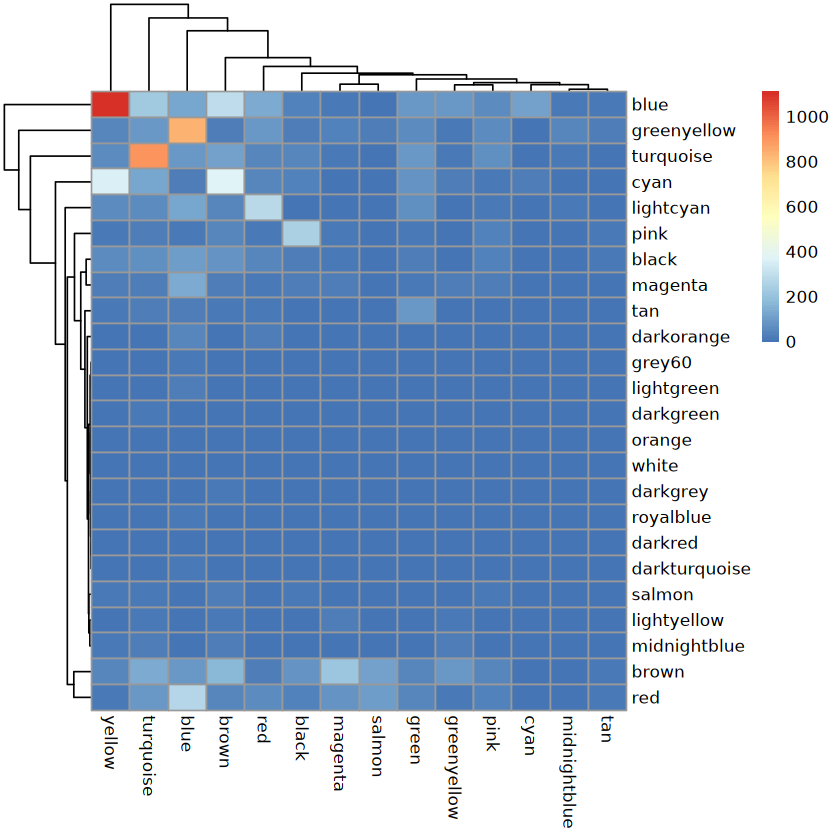

In [12]:
pheatmap::pheatmap(overlap)

so phase 2 yellow and phase 1 blue modules are similar to each other?